
# Recognizing hand-written digits

In this task  you'll be working with the hand-written digits dataset from scikit-learn.

In [1]:
#1st step importing the libraries 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

## Digits dataset

The digits dataset consists of 1797 8x8 images

In [2]:
from sklearn import datasets
digits = datasets.load_digits()
X=digits.data # the 8x8 images
y=digits.target # the digit they belong to

## Question 1) Plot the first image 

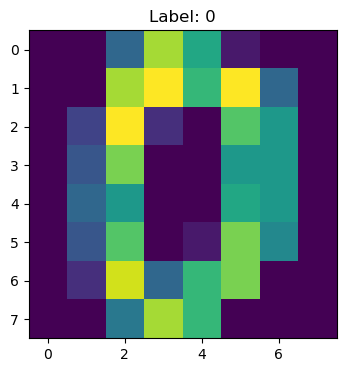

In [3]:
first_image = digits.images[0]
plt.figure(figsize=(4, 4))
plt.imshow(first_image, cmap='viridis')
plt.title(f"Label: {digits.target[0]}")
# plt.axis('off')
plt.show()

## Question 2) Creat a loop that plots the first of each digit, for example first 0, first 1, first 2... the output should look like this

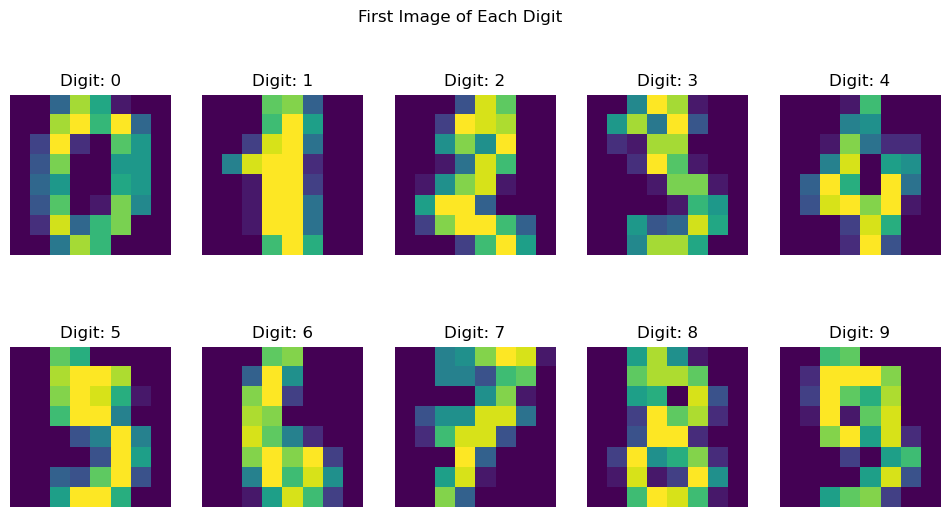

In [7]:
# Creating a figure to hold subplots for each digit
fig, axs = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('First Image of Each Digit')

# Loop through each digit (0 to 9)
for digit in range(10):
    # Find the index of the first occurrence of the current digit
    index = next((idx for idx, label in enumerate(digits.target) if label == digit), None)
    
    # obtaining pixel values of the first image for the current digit
    first_image = digits.images[index]
    
    # Ploting the image in the corresponding subplot
    ax = axs[digit // 5, digit % 5] 
    ax.imshow(first_image, cmap='viridis')  
    ax.set_title(f"Digit: {digit}")  
    ax.axis('off')  # Turn off axis labels

# plt.tight_layout()
# plt.show()


## Question 3) Split the data into train and test (50-50 split), an appropriately apply any scaling 

In [8]:
# Spliting the data into features (X) and labels (y)
X = digits.data
y = digits.target

# Spliting the data into training and testing sets (50-50 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

#scaling (StandardScaler) to the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#StandardScaler will remove the mean and scale each feature to unit value

## Question 4) Apply three approporiate models, and evaluate the results 

## SVM MODEL

In [12]:
# Initializing the svm model first 
svm_model = SVC(kernel='rbf', gamma='scale', C=1.0)

# Training the model based on the scaled training data 


In [13]:
svm_model.fit(X_train_scaled, y_train)

SVC()

# Predicting the model 


In [14]:
svm_pred = svm_model.predict(X_test_scaled)

# Evaluating the model


In [15]:
svm_accuracy = accuracy_score(y_test, svm_pred)

# Printing the accuracy for the model 

In [16]:
print(f"SVM Accuracy: {svm_accuracy}")

SVM Accuracy: 0.9688542825361512


## Printing a classification report the SVM model

In [17]:
print("\nClassification Report for SVM:")
print(classification_report(y_test, svm_pred))


Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        82
           1       0.99      0.99      0.99        89
           2       0.96      0.99      0.98        83
           3       0.97      0.91      0.94        93
           4       0.97      0.99      0.98        93
           5       0.97      0.97      0.97        99
           6       0.99      0.98      0.98        98
           7       0.97      0.99      0.98        87
           8       0.91      0.95      0.93        83
           9       0.98      0.92      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899



## RANDOMFOREST MODEL 

In [18]:
# Initializing the RF model  
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the model based on the scaled training data

In [19]:
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

# Predicting the model

In [20]:
rf_pred = rf_model.predict(X_test_scaled)

# Evaluating the model

In [21]:
rf_accuracy = accuracy_score(y_test, rf_pred)

# Printing the accuracy for the model

In [22]:
print(f"Random Forest Accuracy: {rf_accuracy}")

Random Forest Accuracy: 0.9577308120133482


## Printing a classification report the Random Forest model

In [23]:
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, rf_pred))


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        82
           1       0.96      0.98      0.97        89
           2       0.98      0.98      0.98        83
           3       1.00      0.88      0.94        93
           4       0.96      0.98      0.97        93
           5       0.98      0.93      0.95        99
           6       0.99      0.98      0.98        98
           7       0.93      0.99      0.96        87
           8       0.89      0.94      0.91        83
           9       0.92      0.95      0.93        92

    accuracy                           0.96       899
   macro avg       0.96      0.96      0.96       899
weighted avg       0.96      0.96      0.96       899



# Multi-layer perceptron model.

In [24]:
#Initializing the mlp model 
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)

# Training the model based on the scaled training data

In [25]:
mlp_model.fit(X_train_scaled, y_train)

MLPClassifier(max_iter=500, random_state=42)

# Predicting the model

In [26]:
mlp_pred = mlp_model.predict(X_test_scaled)

# Evaluating  the model

In [27]:
mlp_accuracy = accuracy_score(y_test, mlp_pred)

# Printing the accuracy for the model

In [28]:
print(f"MLP Accuracy: {mlp_accuracy}")

MLP Accuracy: 0.9699666295884316


# Printing a classification report the MLP model

In [29]:
print(classification_report(y_test, mlp_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        82
           1       0.98      0.99      0.98        89
           2       0.97      1.00      0.98        83
           3       0.99      0.89      0.94        93
           4       0.99      0.98      0.98        93
           5       0.99      0.97      0.98        99
           6       0.99      0.98      0.98        98
           7       0.95      0.99      0.97        87
           8       0.90      0.96      0.93        83
           9       0.97      0.95      0.96        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899



## Question 5) Create a new dataset called X_new, which takes every 4 pixles of the X as a feature. The resulting data should have the following dimensions 

For example: the first column of X_new should be the mean of the first four columns of X, the second column of X_new should be the mean of the next four columns(columns 5,6,7,8) of X

In [30]:
# Reshaping X to have dimensions
num_samples, num_pixels = X.shape[0], X.shape[1]
pixels_per_group = 4  # Grouping 4 pixels together
num_new_features = num_pixels // pixels_per_group  # Number of new features in X_new

# calculating mean of every 4 pixels
X_reshaped = X.reshape(num_samples, -1, pixels_per_group)
X_new = np.mean(X_reshaped, axis=2)  # Calculate mean along the third axis

# Checking the dimensions of X_new
print(f"Original X shape: {X.shape}")
print(f"X_new shape: {X_new.shape}")


Original X shape: (1797, 64)
X_new shape: (1797, 16)


In [31]:
X_new

array([[4.5 , 2.5 , 7.  , ..., 5.5 , 4.75, 2.5 ],
       [3.  , 4.5 , 2.75, ..., 5.5 , 2.75, 6.5 ],
       [1.  , 6.75, 4.75, ..., 8.  , 0.75, 9.  ],
       ...,
       [3.  , 4.  , 7.25, ..., 7.75, 2.75, 4.75],
       [3.  , 1.75, 7.5 , ..., 6.25, 4.25, 7.  ],
       [6.  , 2.25, 8.  , ..., 8.  , 5.25, 6.75]])

In [32]:
X_new.shape

(1797, 16)

## Question 6) Split the data into train and test (50-50 split), an appropriately apply any scaling to X_new 

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Spliting the X_new data into training and testing sets (50-50 split)
X_new_train, X_new_test, y_train, y_test = train_test_split(X_new, y, test_size=0.5, random_state=42)

# Applying scaling (StandardScaler) to the features in X_new
scaler = StandardScaler()
X_new_train_scaled = scaler.fit_transform(X_new_train)
X_new_test_scaled = scaler.transform(X_new_test)

## Question 7) Apply three approporiate models, and evaluate the results

# Creating new models based on the new shape 

# SVM MODEL 

In [35]:
# Initializing the SVM model
svm_model = SVC(kernel='rbf', gamma='scale', C=1.0)

# Training the model based on the new training data

In [36]:
svm_model.fit(X_new_train_scaled, y_train)

SVC()

# Predicting the model based on the new data

In [37]:
svm_pred = svm_model.predict(X_new_test_scaled)

# Evaluting the new model

In [38]:
svm_accuracy = accuracy_score(y_test, svm_pred)

# Printing the accuracy for the new model

In [39]:
print(f"SVM Accuracy: {svm_accuracy}")

SVM Accuracy: 0.949944382647386


# Printing a classification report for the new SVM model

In [40]:
print("\nClassification Report for SVM:")
print(classification_report(y_test, svm_pred))


Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91        82
           1       0.93      0.88      0.90        89
           2       0.98      0.98      0.98        83
           3       0.97      0.96      0.96        93
           4       0.97      0.98      0.97        93
           5       0.98      0.98      0.98        99
           6       0.99      0.98      0.98        98
           7       0.98      0.99      0.98        87
           8       0.81      0.92      0.86        83
           9       0.96      0.96      0.96        92

    accuracy                           0.95       899
   macro avg       0.95      0.95      0.95       899
weighted avg       0.95      0.95      0.95       899



# Random Forest Model

In [41]:
#Initializing the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the model based on the new training data

In [42]:
rf_model.fit(X_new_train_scaled, y_train)

RandomForestClassifier(random_state=42)

# Predicting the model based on the new data

In [43]:
rf_pred = rf_model.predict(X_new_test_scaled)

# Evaluting the new model

In [44]:
rf_accuracy = accuracy_score(y_test, rf_pred)

# Printing the accuracy for the new model

In [45]:
print(f"Random Forest Accuracy: {rf_accuracy}")

Random Forest Accuracy: 0.9299221357063404


# Printing a classification report for the new RF model

In [46]:
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, rf_pred))


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        82
           1       0.90      0.90      0.90        89
           2       0.89      0.94      0.91        83
           3       0.95      0.83      0.89        93
           4       0.97      0.99      0.98        93
           5       0.99      0.95      0.97        99
           6       1.00      0.97      0.98        98
           7       0.91      0.99      0.95        87
           8       0.85      0.84      0.85        83
           9       0.92      0.93      0.93        92

    accuracy                           0.93       899
   macro avg       0.93      0.93      0.93       899
weighted avg       0.93      0.93      0.93       899



# Multi-layer perceptron model.

In [47]:
#Initializing the model
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)


# Training the model based on the new training data

In [48]:
mlp_model.fit(X_new_train_scaled, y_train)


MLPClassifier(max_iter=500, random_state=42)

# Predicting the model based on the new data


In [50]:
mlp_pred = mlp_model.predict(X_new_test_scaled)

# Evaluting the new model

In [52]:
mlp_accuracy = accuracy_score(y_test, mlp_pred)

# Printing the accuracy for the new model


In [53]:
print(f"MLP Accuracy: {mlp_accuracy}")

MLP Accuracy: 0.92880978865406


# Printing a classification report for the new MLP model

In [55]:
print("\nClassification Report for MLP:")
print(classification_report(y_test, mlp_pred))


Classification Report for MLP:
              precision    recall  f1-score   support

           0       0.89      0.90      0.90        82
           1       0.93      0.88      0.90        89
           2       0.92      0.96      0.94        83
           3       0.95      0.87      0.91        93
           4       0.98      0.98      0.98        93
           5       0.98      0.92      0.95        99
           6       0.99      0.97      0.98        98
           7       0.96      0.99      0.97        87
           8       0.78      0.86      0.82        83
           9       0.91      0.96      0.93        92

    accuracy                           0.93       899
   macro avg       0.93      0.93      0.93       899
weighted avg       0.93      0.93      0.93       899



# Question 8) Discuss the difference in the results form Q4 and Q6

In [ ]:
# for the first answer, before changing the dimensions the svm model and the mlp
# had an accuracy of 97% and the randomforest had 95% accuracy. But after changing the 
# dimensions there was a significant drop in the accuracy for all the models even 
# the f1 score, precision and recall had a decrease in their values. The svm model had 
# a good overall even after changing the dimensions. As a result change in dimension
# # has affected the performance of the model. 

# Refrences

In [ ]:
# “Sklearn.neural_network.MLPClassifier — Scikit-Learn 0.20.3 Documentation.” Scikit-Learn.org, 2010, scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html. Accessed 11 Dec. 2023.